# Перегляд погодинних даних про тривоги

Блокнот для постійного перегляду `data/processed/{region}_hourly.parquet`.
Перезапускай комірки (Run All), щоб підхопити свіжі дані після нового запуску `preprocess/build_grid.py`.

In [1]:
import pandas as pd

pd.set_option("display.max_rows", 50)
pd.set_option("display.width", 120)

try:
    kyiv = pd.read_parquet("data/processed/kyiv_hourly.parquet")
    nikopol = pd.read_parquet("data/processed/nikopol_hourly.parquet")
except Exception:
    from preprocess.build_grid import build_hourly_grid
    kyiv = build_hourly_grid("kyiv")
    nikopol = build_hourly_grid("nikopol")

regions = {"kyiv": kyiv, "nikopol": nikopol}

## Загальна інформація

In [2]:
for key, df in regions.items():
    print(f"--- {key} ---")
    print("shape:", df.shape)
    print("index dtype:", df.index.dtype)
    print("діапазон:", df.index.min(), "->", df.index.max())
    print("частка alert_active:", round(df["alert_active"].mean(), 4))
    print()

--- kyiv ---
shape: (37333, 3)
index dtype: datetime64[us, Europe/Kyiv]
діапазон: 2022-03-15 18:00:00+02:00 -> 2026-06-18 07:00:00+03:00
частка alert_active: 0.1188

--- nikopol ---
shape: (37370, 3)
index dtype: datetime64[us, Europe/Kyiv]
діапазон: 2022-03-15 21:00:00+02:00 -> 2026-06-19 23:00:00+03:00
частка alert_active: 0.7569



## Київ — перші рядки

In [3]:
kyiv.head(20)

,alert_active,alert_minutes,n_starts
hour,,,
2022-03-15 18:00:00+02:00,1,40.666667,2
2022-03-15 19:00:00+02:00,1,60.000000,0
2022-03-15 20:00:00+02:00,1,52.466667,0
2022-03-15 21:00:00+02:00,0,0.000000,0
2022-03-15 22:00:00+02:00,0,0.000000,0
2022-03-15 23:00:00+02:00,0,0.000000,0
2022-03-16 00:00:00+02:00,0,0.000000,0
2022-03-16 01:00:00+02:00,1,26.216667,2
2022-03-16 02:00:00+02:00,1,60.000000,0


## Нікопольська громада — перші рядки

In [4]:
nikopol.head(20)

,alert_active,alert_minutes,n_starts
hour,,,
2022-03-15 21:00:00+02:00,1,18.316667,2
2022-03-15 22:00:00+02:00,0,0.000000,0
2022-03-15 23:00:00+02:00,0,0.000000,0
2022-03-16 00:00:00+02:00,0,0.000000,0
2022-03-16 01:00:00+02:00,0,0.000000,0
2022-03-16 02:00:00+02:00,1,43.600000,4
2022-03-16 03:00:00+02:00,1,60.000000,0
2022-03-16 04:00:00+02:00,1,60.000000,0
2022-03-16 05:00:00+02:00,1,60.000000,0


## Базова статистика

In [5]:
for key, df in regions.items():
    print(f"--- {key} ---")
    display(df.describe())

--- kyiv ---


,alert_active,alert_minutes,n_starts
count,37333.000000,37333.000000,37333.000000
mean,0.118849,3.940957,0.105831
std,0.323615,12.823251,0.448005
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000
max,1.000000,60.000000,4.000000


--- nikopol ---


,alert_active,alert_minutes,n_starts
count,37370.000000,37370.000000,37370.000000
mean,0.756891,36.488588,0.643324
std,0.428966,25.803118,1.085162
min,0.000000,0.000000,0.000000
25%,1.000000,1.820833,0.000000
50%,1.000000,49.816667,0.000000
75%,1.000000,60.000000,2.000000
max,1.000000,60.000000,8.000000


## Динаміка по днях (частка годин під тривогою)

Інтерактивний графік (Plotly) із range slider під осями — тягни краї або
використовуй кнопки періодів (1м/3м/6м/1р/все), щоб наближати/віддаляти
певний відрізок часу.
Потребує `plotly` (`pip install plotly`), якщо ще не встановлено.

In [6]:
import plotly.graph_objects as go

fig = go.Figure()
for key, df in regions.items():
    daily_share = df["alert_active"].resample("D").mean()
    fig.add_trace(go.Scatter(
        x=daily_share.index,
        y=daily_share.values,
        mode="lines",
        name=key,
        opacity=0.85,
    ))

fig.update_layout(
    title="Частка годин під тривогою за день",
    xaxis_title="Дата",
    yaxis_title="Частка годин (0..1)",
    height=500,
    xaxis=dict(
        rangeslider=dict(visible=True),
        type="date",
        rangeselector=dict(
            buttons=[
                dict(count=1, label="1м", step="month", stepmode="backward"),
                dict(count=3, label="3м", step="month", stepmode="backward"),
                dict(count=6, label="6м", step="month", stepmode="backward"),
                dict(count=1, label="1р", step="year", stepmode="backward"),
                dict(step="all", label="все"),
            ]
        ),
    ),
    yaxis=dict(range=[0, 1]),
)
fig.show()

## Довільний перегляд за конкретний період

Зміни `start`/`end`, щоб подивитись на конкретний відрізок часу.

In [7]:
start = "2026-06-01"
end = "2026-06-20"

for key, df in regions.items():
    print(f"--- {key}: {start} .. {end} ---")
    display(df.loc[start:end])

--- kyiv: 2026-06-01 .. 2026-06-20 ---


,alert_active,alert_minutes,n_starts
hour,,,
2026-06-01 00:00:00+03:00,0,0.000000,0
2026-06-01 01:00:00+03:00,0,0.000000,0
2026-06-01 02:00:00+03:00,0,0.000000,0
2026-06-01 03:00:00+03:00,0,0.000000,0
2026-06-01 04:00:00+03:00,0,0.000000,0
...,...,...,...
2026-06-18 03:00:00+03:00,0,0.000000,0
2026-06-18 04:00:00+03:00,1,57.916667,1
2026-06-18 05:00:00+03:00,1,42.200000,0


--- nikopol: 2026-06-01 .. 2026-06-20 ---


,alert_active,alert_minutes,n_starts
hour,,,
2026-06-01 00:00:00+03:00,1,60.000000,0
2026-06-01 01:00:00+03:00,1,60.000000,0
2026-06-01 02:00:00+03:00,1,60.000000,0
2026-06-01 03:00:00+03:00,1,60.000000,1
2026-06-01 04:00:00+03:00,1,60.000000,0
...,...,...,...
2026-06-19 19:00:00+03:00,1,26.850000,1
2026-06-19 20:00:00+03:00,1,33.400000,0
2026-06-19 21:00:00+03:00,1,16.983333,1


---
# EDA: добові, тижневі, місячні закономірності

Розвідувальний аналіз для обох регіонів поруч: година доби, день тижня,
heatmap (година × день тижня), динаміка по місяцях/роках, розподіл тривалості тривог.

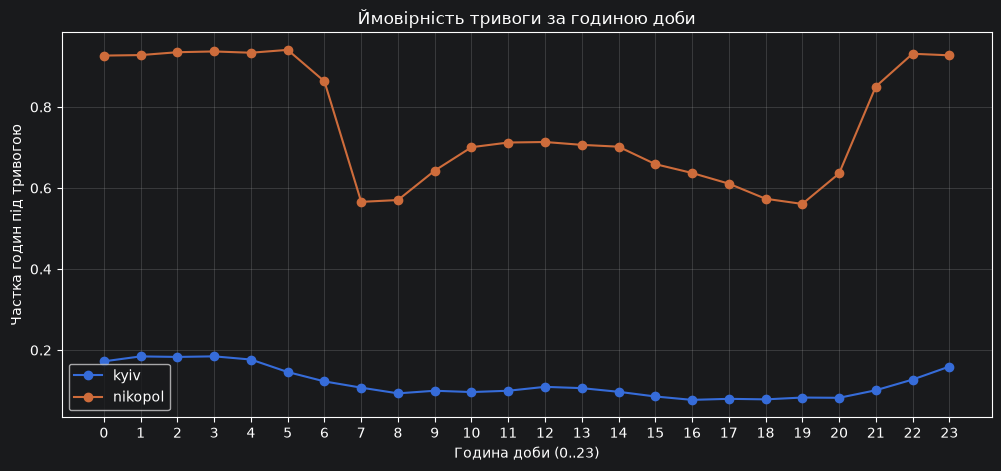

In [8]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 5))
for key, df in regions.items():
    by_hour = df.groupby(df.index.hour)["alert_active"].mean()
    ax.plot(by_hour.index, by_hour.values, marker="o", label=key)

ax.set_title("Ймовірність тривоги за годиною доби")
ax.set_xlabel("Година доби (0..23)")
ax.set_ylabel("Частка годин під тривогою")
ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(alpha=0.3)
plt.show()

**Висновок:** виражений добовий ритм — вночі тривог помітно більше, ніж удень,
в обох регіонах. У Києві ймовірність тривоги вночі (0–5 год) ~17–18%, удень (9–18 год) ~9–10%.
У Нікополі вночі ~91%, удень ~54–55% — нічний пік ще різкіший за абсолютним рівнем.

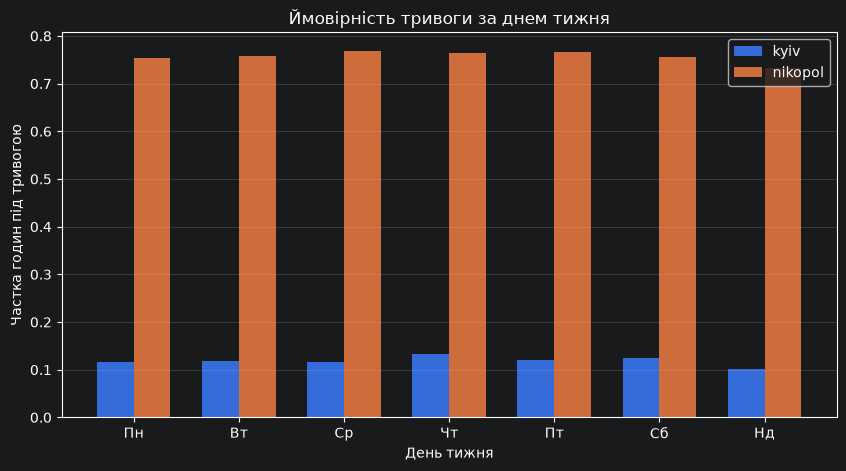

In [9]:
dow_labels = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Нд"]

fig, ax = plt.subplots(figsize=(10, 5))
width = 0.35
x = np.arange(7)
for i, (key, df) in enumerate(regions.items()):
    by_dow = df.groupby(df.index.dayofweek)["alert_active"].mean()
    ax.bar(x + i * width, by_dow.values, width=width, label=key)

ax.set_title("Ймовірність тривоги за днем тижня")
ax.set_xlabel("День тижня")
ax.set_ylabel("Частка годин під тривогою")
ax.set_xticks(x + width / 2)
ax.set_xticklabels(dow_labels)
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.show()

**Висновок:** день тижня майже не впливає на ймовірність тривоги. У Києві значення
коливаються в межах ~10–13%, у Нікополі ~66–68% — розкид між найспокійнішим і
найнапруженішим днем тижня в обох регіонах не перевищує кількох відсоткових пунктів.

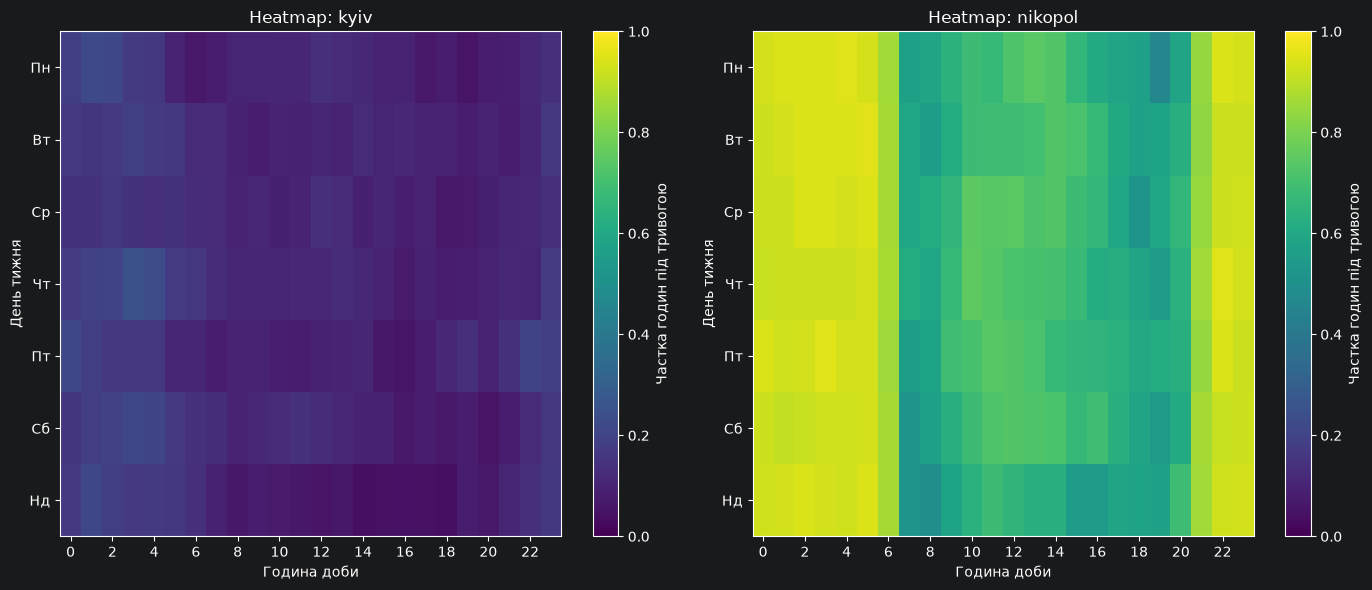

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (key, df) in zip(axes, regions.items()):
    pivot = (
        df.assign(hour_of_day=df.index.hour, weekday=df.index.dayofweek)
        .groupby(["weekday", "hour_of_day"])["alert_active"]
        .mean()
        .unstack("hour_of_day")
    )
    im = ax.imshow(pivot.values, aspect="auto", cmap="viridis", vmin=0, vmax=1)
    ax.set_title(f"Heatmap: {key}")
    ax.set_xlabel("Година доби")
    ax.set_ylabel("День тижня")
    ax.set_xticks(range(0, 24, 2))
    ax.set_xticklabels(range(0, 24, 2))
    ax.set_yticks(range(7))
    ax.set_yticklabels(dow_labels)
    fig.colorbar(im, ax=ax, label="Частка годин під тривогою")

plt.tight_layout()
plt.show()

**Висновок:** на heatmap чітко видно вертикальні (годинні) смуги, а не горизонтальні
(денні) — тобто структуру визначає саме час доби, а не день тижня. Це узгоджується
з пунктами 1 і 2 вище.

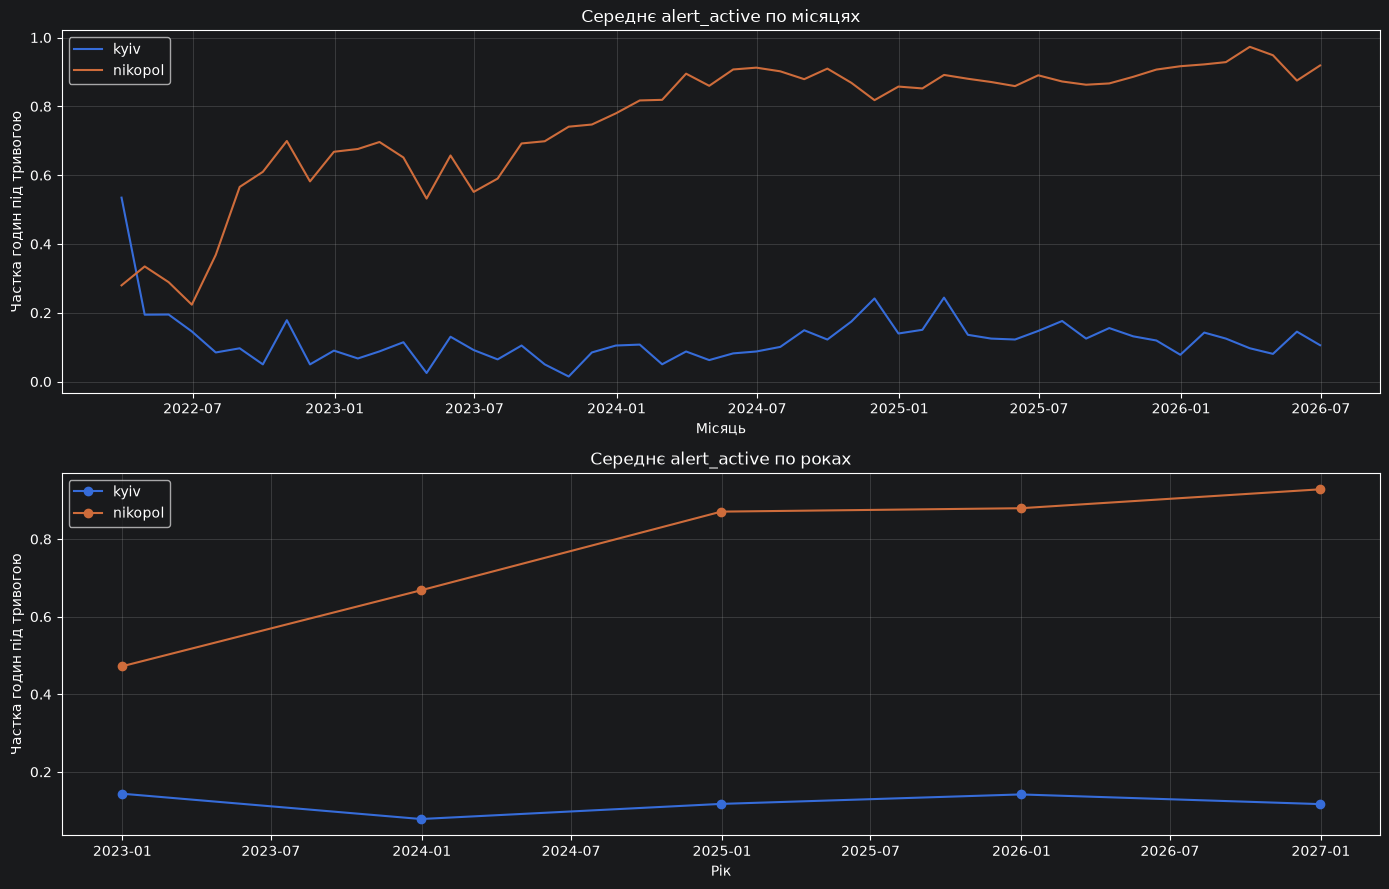

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)

ax = axes[0]
for key, df in regions.items():
    monthly = df["alert_active"].resample("ME").mean()
    ax.plot(monthly.index, monthly.values, label=key)
ax.set_title("Середнє alert_active по місяцях")
ax.set_xlabel("Місяць")
ax.set_ylabel("Частка годин під тривогою")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
for key, df in regions.items():
    yearly = df["alert_active"].resample("YE").mean()
    ax.plot(yearly.index, yearly.values, marker="o", label=key)
ax.set_title("Середнє alert_active по роках")
ax.set_xlabel("Рік")
ax.set_ylabel("Частка годин під тривогою")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Висновок:** Нікополь демонструє сильний висхідний тренд по роках — з ~29% у 2022
до ~93% у 2026 (майже постійний стан тривоги до кінця періоду). Київ натомість
залишається стабільним по роках, коливаючись у вузькому діапазоні ~8–14% без
вираженого тренду.

kyiv: n=2077, медіана=0.64 год, середнє=1.18 год, 90-й перцентиль=2.71 год, максимум=10.52 год
nikopol: n=7917, медіана=1.00 год, середнє=2.87 год, 90-й перцентиль=9.90 год, максимум=42.28 год


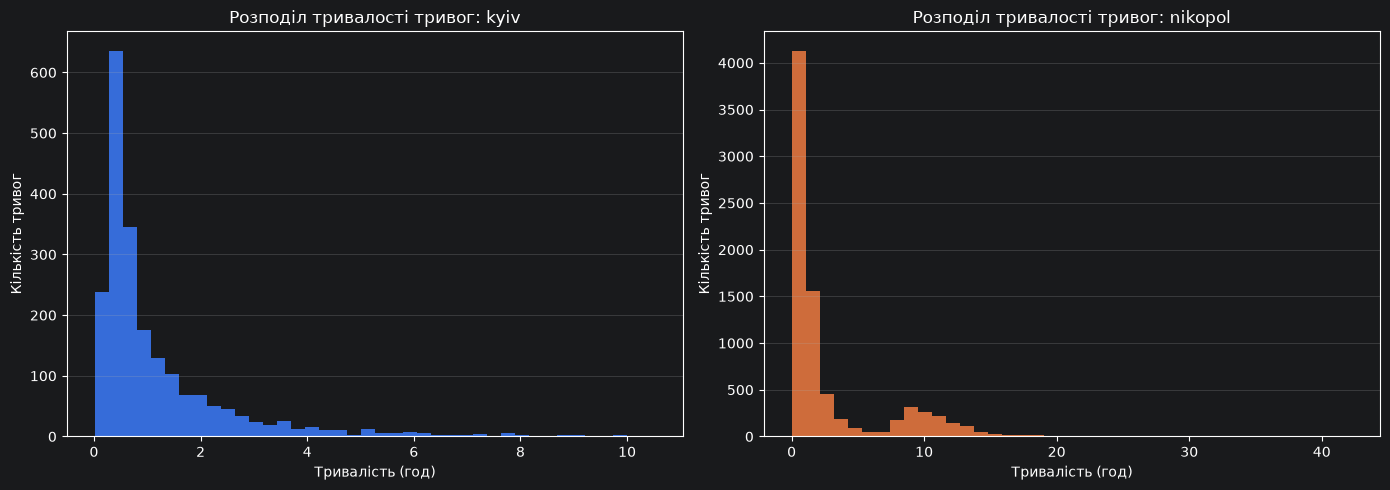

In [12]:
from data.load import load_region
from preprocess.build_grid import merge_intervals

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, key in zip(axes, regions.keys()):
    raw = load_region(key)
    merged = merge_intervals(raw)
    duration_hours = (merged["finished_at"] - merged["started_at"]).dt.total_seconds() / 3600

    ax.hist(duration_hours, bins=40, color="C0" if key == "kyiv" else "C1")
    ax.set_title(f"Розподіл тривалості тривог: {key}")
    ax.set_xlabel("Тривалість (год)")
    ax.set_ylabel("Кількість тривог")
    ax.grid(alpha=0.3, axis="y")
    print(
        f"{key}: n={len(merged)}, медіана={duration_hours.median():.2f} год, "
        f"середнє={duration_hours.mean():.2f} год, "
        f"90-й перцентиль={duration_hours.quantile(0.9):.2f} год, "
        f"максимум={duration_hours.max():.2f} год"
    )

plt.tight_layout()
plt.show()

**Висновок:** розподіл тривалості тривог сильно зкошений праворуч (багато коротких,
кілька дуже довгих). У Києві медіана ~0.6 год (мінімум 90-й перцентиль ~2.7 год,
максимум ~10.5 год). У Нікополі тривоги довші: медіана ~1.3 год, 90-й перцентиль
~10.3 год, максимум сягає ~42 год — узгоджується з майже безперервним станом
тривоги, видимим на графіках динаміки.

## Підсумкові висновки

1. **Добовий ритм виражений в обох регіонах**: вночі тривоги помітно частіші, ніж
   удень. Київ: ~17% ніч проти ~9% день. Нікополь: ~91% ніч проти ~54–55% день.
2. **День тижня практично не впливає** — розкид між днями тижня в межах кількох
   відсоткових пунктів і для Києва (~10–13%), і для Нікополя (~66–68%).
3. **Heatmap підтверджує**: структура визначається годиною доби (вертикальні смуги),
   а не днем тижня (відсутні горизонтальні смуги).
4. **Річна динаміка протилежна для двох регіонів**: Нікополь має сильний висхідний
   тренд — з ~29% у 2022 до ~93% у 2026 (фактично майже постійний стан тривоги
   наприкінці періоду). Київ стабільний, без тренду, в діапазоні ~8–14%.
5. **Загальний рівень тривожності різний на порядок**: Нікополь під тривогою ~67%
   усього часу спостереження, Київ — лише ~12%.
6. **Тривалість окремих тривог теж різна**: у Києві типова тривога коротка
   (медіана ~0.6 год), у Нікополі — довша (медіана ~1.3 год), із суттєво важчим
   "хвостом" довгих тривог (до ~42 год проти ~10.5 год у Києві).
7. **Інтерпретація**: Нікополь, як прифронтова громада, з часом перейшов у режим
   майже безперервної загрози (особливо вночі), тоді як Київ зберігає відносно
   стабільний і помітно нижчий рівень ризику впродовж усього періоду спостережень.